# datars in notebooks — a quickstart

datars draws **animated, themed data graphics** from DataFrames. A chart is a *document* — the
same one the TypeScript SDK writes — so what you see here plays unchanged on the web, iOS and
Android, and saves pixel-for-pixel to PNG, SVG, PDF and MP4.

In a live notebook each chart is interactive: hover for tooltips, click to highlight, use ← → (or
the buttons) to step through its states. Where scripts don't run (GitHub, nbviewer) you see the
static preview rendered by the same engine.

*The data below is small and illustrative (rounded or synthetic), not statistics.*

In [1]:
import numpy as np
import pandas as pd
import datars as dr

print(dr.__version__)  # dr.options.renderer = "auto": a live widget with anywidget installed, else HTML that goes live

0.1.0


## 1. A chart from a DataFrame

Column names in, a chart out. Scale types come from dtypes (text → categories, numbers → linear,
dates → time); the category is the bar's *key* — its identity when the chart changes.

In [2]:
votes = pd.DataFrame({
    "party": ["S", "SD", "M", "V", "C", "KD", "MP", "L"],
    "share": [30.3, 20.5, 19.1, 6.8, 6.7, 5.3, 5.1, 4.6],
})
names = {"S": "Social Democrats", "SD": "Sweden Democrats", "M": "Moderates", "V": "Left",
         "C": "Centre", "KD": "Christian Democrats", "MP": "Greens", "L": "Liberals"}

dr.bar(votes, x="party", y="share", color="party", names=names, labels=True,
       title="Vote share, Swedish election 2022 (%)")

<datars Chart 'Vote share, Swedish election 2022 (%)' 720×440, 8 rows>

## 2. Themes

Built-in looks (`"neutral"`, `"noir"`, `"broadsheet"`) or your brand's tokens. Colours stay
late-bound, so dark mode and re-theming never rebuild the chart.

In [3]:
brand = dr.theme("neutral", accent="#0a7d6b", mark="#0a7d6b",
                 categorical={"generate": "categorical", "from": "#0a7d6b", "n": 8})

dr.row(
    dr.bar(votes, x="share", y="party", sort="desc", theme="noir", title="Noir"),
    dr.bar(votes, x="share", y="party", sort="desc", theme=brand, title="Your brand"),
)

<datars Layout 'chart' 1400×440, 8 rows>

## 3. Lines from a wide frame — `df.plot()` style

No `y`: one line per numeric column against the index. Few series are labelled at their ends
instead of a legend. Reference lines, bands and callouts take data coordinates.

In [4]:
days = pd.date_range("2024-01-01", periods=120, freq="D", name="day")
t = np.arange(120)
prices = pd.DataFrame({
    "north": 40 + 25 * np.cos(t / 19) + 4 * np.sin(t * 0.7),
    "south": 55 + 20 * np.cos(t / 23 + 1) + 5 * np.sin(t * 0.5),
}, index=days).round(1)

(dr.line(prices, title="Spot price, öre/kWh")
   .rule(y=50, label="Budget")
   .span(x=("2024-02-10", "2024-02-24"), label="Cold spell"))

<datars Chart 'Spot price, öre/kWh' 720×440, 240 rows>

## 4. Distributions — `plt.hist`, `sns.histplot`

`bins` and `range` as in numpy; a bin count gets round edges unless `nice=False`. `color=`
stacks groups.

In [5]:
rng = np.random.default_rng(1)
people = pd.DataFrame({
    "height": np.r_[rng.normal(165, 7, 1500), rng.normal(179, 7, 1500)].round(1),
    "group": ["A"] * 1500 + ["B"] * 1500,
})
dr.hist(people, x="height", color="group", bins=30, title="Heights (cm)")

<datars Chart 'Heights (cm)' 720×440, 50 rows>

## 5. Animation: `frame=` — datars' superpower

Like plotly's `animation_frame`: one state per value of the column, played automatically (and
steppable). `key=` says what stays the same thing across frames — each country's dot *moves*
from year to year instead of blinking. Axes hold still over the whole data.

In [6]:
countries = {"Sweden": "Europe", "Germany": "Europe", "USA": "Americas", "Brazil": "Americas",
             "Mexico": "Americas", "China": "Asia", "India": "Asia", "Japan": "Asia",
             "Nigeria": "Africa", "Ethiopia": "Africa"}
rows = []
for i, (c, cont) in enumerate(countries.items()):
    g, life, pop = 900 * (1 + i) ** 1.2, 42 + 3.2 * i, 8 + 11 * i
    for year in range(1960, 2021, 5):
        rows.append({"country": c, "continent": cont, "year": year, "gdp per capita": round(g),
                     "life expectancy": round(life, 1), "population": round(pop, 1)})
        g *= 1.06 + 0.05 * rng.random(); life += 1.1 + 0.8 * rng.random(); pop *= 1.04 + 0.03 * rng.random()
gap = pd.DataFrame(rows)

dr.scatter(gap, x="gdp per capita", y="life expectancy", size="population", color="continent",
           frame="year", key="country", label="country", log_x=True,
           title="Richer, and living longer (synthetic data)")

<datars Chart 'Richer, and living longer (synthetic data)' 720×440, 130 rows, 13 states>

Sorting by value inside each frame makes a **bar chart race** — bars overtake each other.

In [7]:
dr.bar(gap, x="gdp per capita", y="country", color="continent", frame="year", sort="desc",
       title="GDP per capita (synthetic)", height=420)

<datars Chart 'GDP per capita (synthetic)' 720×420, 130 rows, 13 states>

## 6. Stories: charts that morph into each other

`dr.story` makes each chart a step. Marks with the same key morph — a party's bar becomes its
slice — and the narration is drawn by the engine (so it's in the PNG and MP4 too).

In [8]:
story = dr.story(
    (dr.bar(votes, x="party", y="share", color="party", names=names, title="Vote share (%)"),
     "Eight parties made it into the Riksdag.", "2022"),
    (dr.bar(votes, x="share", y="party", color="party", names=names, sort="desc", title="Ranked"),
     "The Social Democrats stayed the largest."),
    (dr.pie(votes, names="party", values="share"), "Each bar becomes a slice."),
    (dr.donut(votes, names="party", values="share"), "A donut frees the middle for the total."),
)
story

<datars Story 'Vote share (%)' 720×440, 16 rows, 4 states>

Or give one chart several states: highlight what matters at each step.

In [9]:
(dr.bar(votes, x="party", y="share", color="party", names=names, labels=True)
   .step("All parties")
   .step("Government", highlight=["M", "KD", "L"], text="The Moderates, Christian Democrats and Liberals formed the government …")
   .step("Support", highlight=["M", "KD", "L", "SD"], text="… with the Sweden Democrats' support."))

<datars Chart 'chart' 720×440, 8 rows, 3 states>

## 7. Maps

A choropleth over the built-in countries atlas (ISO 3166 alpha-3 codes), or your own GeoJSON /
a GeoPandas frame (`source=gdf`).

<datars Chart 'Renewable share of energy use (%)' 720×440, 18 rows>
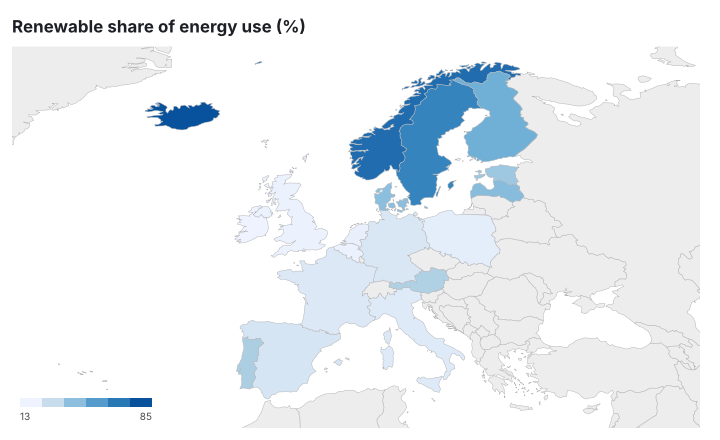

In [10]:
renew = pd.DataFrame({"iso": ["ISL", "NOR", "SWE", "FIN", "DNK", "LVA", "EST", "PRT", "AUT", "DEU", "FRA", "ESP", "ITA", "POL", "NLD", "GBR", "IRL", "BEL"],
                      "share": [85, 75, 66, 48, 42, 43, 38, 35, 34, 21, 20, 22, 19, 17, 15, 14, 13, 14]})
dr.map(renew, key="iso", value="share", projection="natural-earth", fit={"bbox": [-25, 34, 35, 72]},
       title="Renewable share of energy use (%)")

## 8. Small multiples and layouts

`facet=` repeats a chart per group on shared scales; `|` and `&` (or `dr.row` / `dr.column`) put
charts side by side. Views share signals: click a country's bar and its line lights up next door.

In [11]:
dr.line(gap, x="year", y="life expectancy", color="country", facet="continent", facet_columns=2,
        title="Life expectancy by continent (synthetic)", height=520)

<datars Chart 'Life expectancy by continent (synthetic)' 720×520, 130 rows>

In [12]:
latest = gap[gap.year == 2020]
(dr.bar(latest, x="life expectancy", y="country", sort="desc", title="Life expectancy, 2020 (click a bar)")
 | dr.line(gap, x="year", y="life expectancy", color="country", labels=False, title="Over time"))

<datars Layout 'chart' 1400×440, 140 rows>

## 9. Two-way: the chart as a widget

With `pip install "datars[widget]"` (anywidget) a chart becomes a widget: set its state and
signals from Python, and get clicks back — with the data row behind the mark.

In [13]:
try:
    w = story.widget()
    picked = []
    w.on_click(lambda event: picked.append(event.get("fields")))
    display(w)
except ImportError as err:
    print(err)

In [14]:
# Run after clicking a bar above:  picked  →  [{'party': 'S', 'share': 30.3}]
# Drive it from Python:            w.state = "3";  w.next();  w.set_signal("highlight", ["S"])

## 10. Big data

`dr.cloud` draws any number of points: the engine indexes the rows once into a pyramid and each
frame draws a density-preserving sample of what's in view — every row once you zoom in. (Drag to
pan, scroll to zoom.) Millions of rows work; this notebook keeps 10,000 so it stays small on
disk — `dr.options.digits = 5` rounds floats to shrink big documents.

<datars Chart '10,000 points' 720×440, 10,000 rows>
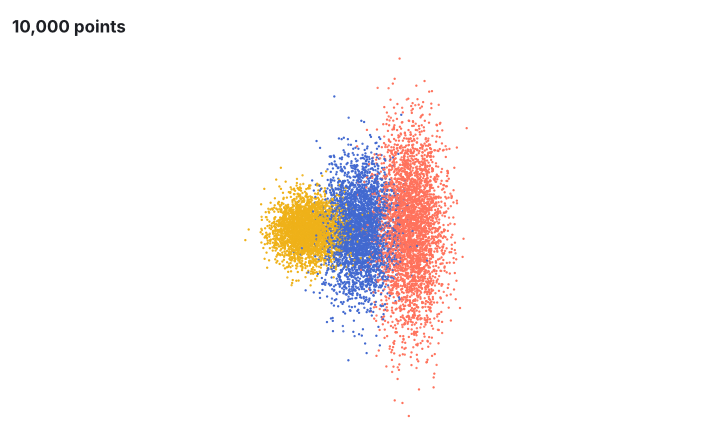

In [15]:
n = 10_000
k = rng.integers(0, 3, n)
pts = pd.DataFrame({"x": rng.normal(0, 1, n) + 3 * k, "y": rng.normal(0, 1, n) * (1 + k),
                    "cluster": np.array(["a", "b", "c"])[k]})
dr.options.digits = 4
cloud = dr.cloud(pts, x="x", y="y", color="cluster", title="10,000 points")
dr.options.digits = None
cloud

## 11. Export

Through the `datars` CLI (`DATARS_CLI` or on `PATH`): one state as PNG/SVG/PDF, the whole
program as an MP4 with captions, a standalone HTML page that works offline, the document JSON, or
a bundle to publish.

In [16]:
import os, tempfile
out = tempfile.mkdtemp()
chart = dr.bar(votes, x="party", y="share", color="party", names=names, title="Vote share (%)")
for name in ["fig.png", "fig.svg", "fig.pdf", "fig.json", "fig.html"]:
    chart.save(os.path.join(out, name))
story.save(os.path.join(out, "story.mp4"), fps=24)
sorted((f, os.path.getsize(os.path.join(out, f))) for f in os.listdir(out))

[('fig.html', 8340871),
 ('fig.json', 1816),
 ('fig.pdf', 38409),
 ('fig.png', 132199),
 ('fig.svg', 21964),
 ('story.mp4', 251112),
 ('story.vtt', 295)]

## 12. Under the hood: the std recipes

Every chart above is built from the standard library's recipes — the same ones TypeScript
authors use. `dr.std` has each one as a typed function (generated from the recipes' own
descriptions); `dr.chart` wraps any of them. Expressions (`dr.e`) run in the engine, per row.

In [17]:
flows = pd.DataFrame({"source": ["Hydro", "Hydro", "Nuclear", "Wind", "Wind", "Solar"],
                      "target": ["Homes", "Industry", "Industry", "Homes", "Export", "Homes"],
                      "TWh": [30, 36, 48, 20, 17, 3]})
dr.chart(dr.std.sankey(data=flows, source="source", target="target", value="TWh"),
         title="Where the electricity goes (illustrative)")

<datars Chart 'Where the electricity goes (illustrative)' 720×440, 6 rows>

In [18]:
print(dr.std.pie.__doc__[:400])

Parts of a whole as slices (set `inner` > 0 for a donut). Colours from the categorical
    palette by category.

    Recipe ``@datars/std/pie``.

    Parameters
    ----------
    category : str
    data : str | DataFrame | Data
    format : str, default ".1~f"
    inner : float, default 0
        Inner radius as a fraction of the outer (0 = pie, 0.6 = donut).
    labels : bool, default True
    p


## 13. Coming from matplotlib

`dr.plot` works without an axes object: `plt.plot(x, y)` → `dr.plot(x, y)`. See the
[guide](../../../docs/guides/python.md) for the full matplotlib / seaborn / plotly mapping.

In [19]:
x = np.linspace(0, 4 * np.pi, 200)
dr.plot(x, np.sin(x) * np.exp(-x / 8), title="Damped oscillation")

<datars Chart 'Damped oscillation' 720×440, 200 rows>